In [2]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
from tqdm import tqdm
import scipy as sp
from copy import deepcopy 


# LISA tools
from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix, AET1SensitivityMatrix

# BBHX: Suppress the print statements from the BBHX module like: "No CuPy or GPU PhenomHM module"
# This is done to avoid cluttering the output when running sp.optimize.differential_evolution
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

with suppress_stdout():
    from bbhx.waveformbuild import BBHWaveformFD

# My modules
from tools.LISASimulator import LISASimulator
from tools.time_freq_likelihood import TimeFreqLikelihood
from tools.likelihood import get_dh, get_hh, TimeFreqSNR
import tools.likelihood as likelihood
from tools.MBHB_differential_evolution import MBHB_finder_time_frequency, MBHB_finder_lisatools, MBHB_finder_frequency_domain, transform_bbhx_to_parameters, transform_parameters_to_bbhx
from tools.save_and_load_DE import save_de_results, load_de_results

from multiprocessing import cpu_count
#print(cpu_count())

gpu = False
if gpu:
    import cupy as cp
else:
    import numpy as cp

In [3]:
np.pi/2

1.5707963267948966

In [4]:
np.cos(np.pi/3)

np.float64(0.5000000000000001)

In [6]:
Tobs = 1.5*YRSID_SI/12
dt = 5.
include_T_channel = False # Set to True if you want to include the T channel in the simulation, otherwise only A and E channels will be included.

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=gpu)

sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.2
a2 = 0.4
dist = 8 * PC_SI * 1e9
phi_ref = np.pi/2
f_ref = 0.0
inc = np.pi/3
lam = np.pi
beta = np.pi/4
psi = np.pi/4
t_ref = Tobs - (24*60*60)

parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

print(sim.SNR_optimal()[0])

1614.3470329756758


(199,) (2001,)


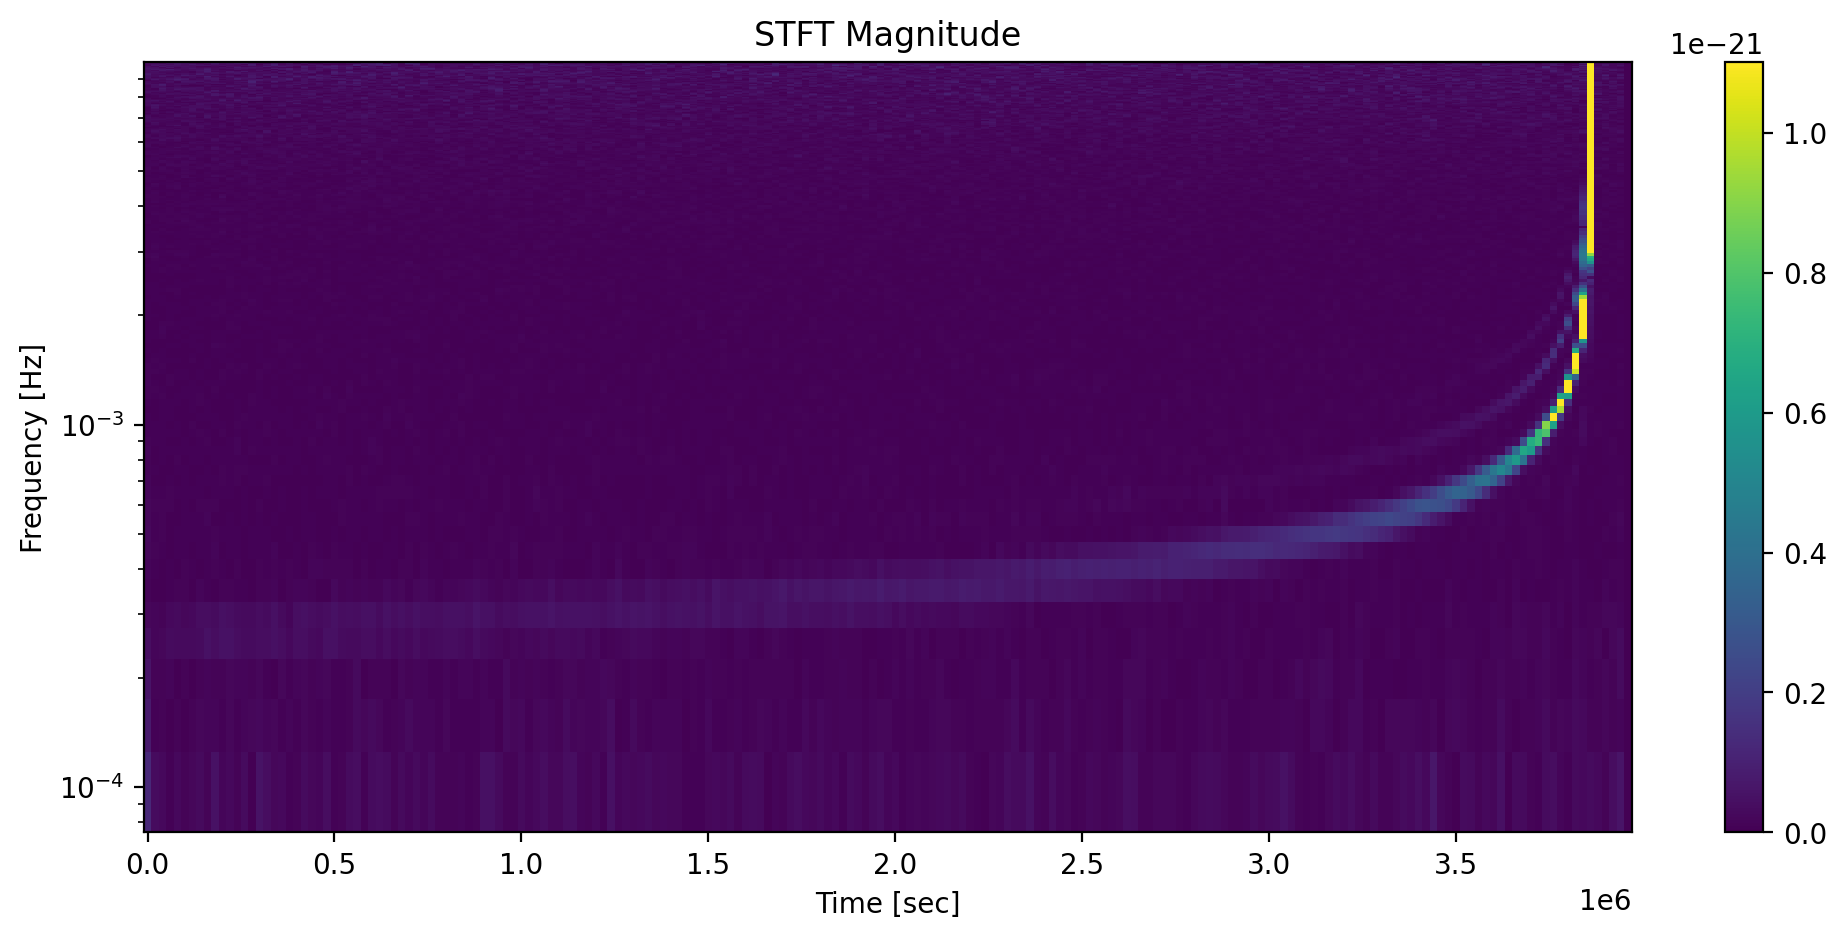

In [7]:
#f, t, Zxx = sp.signal.stft(sim.signal_t[0][0], fs=1/sim.dt, nperseg=5000)
f, t, Zxx = sp.signal.stft(data_t[0], fs=1/sim.dt, nperseg=4000, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 0.01)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
plt.colorbar()

## Pre-Merger

In [8]:
# Not doing the premerger now to see if the code works better with the merger included
hours_before_merger = 10
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60

def pre_merger(gravitational_wave_data_t, time_before_merger, t_ref, t_array):
        cutoff_time = t_ref - time_before_merger
        cutoff_index = np.searchsorted(t_array, cutoff_time)
        data_t_truncated = gravitational_wave_data_t[:, :cutoff_index]
        return data_t_truncated, cutoff_index

data_t_truncated,   cutoff_index =  pre_merger(data_t, time_before_merger, t_ref, t_array)
signal_t_truncated, cutoff_index =  pre_merger(sim.signal_t[0], time_before_merger, t_ref, t_array)

In [9]:
f, t, Zxx = sp.signal.stft(sim.signal_t[0], fs=1/sim.dt, nperseg=3000, noverlap=0)

print(f.shape, t.shape, f.shape[0]*t.shape[0])

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
#plt.xlim(t[-20], t[-3])
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar()

(1501,) (264,) 396264


ValueError: zero-size array to reduction operation maximum which has no identity

<Figure size 1200x500 with 0 Axes>

(1501,) (256,) 384256


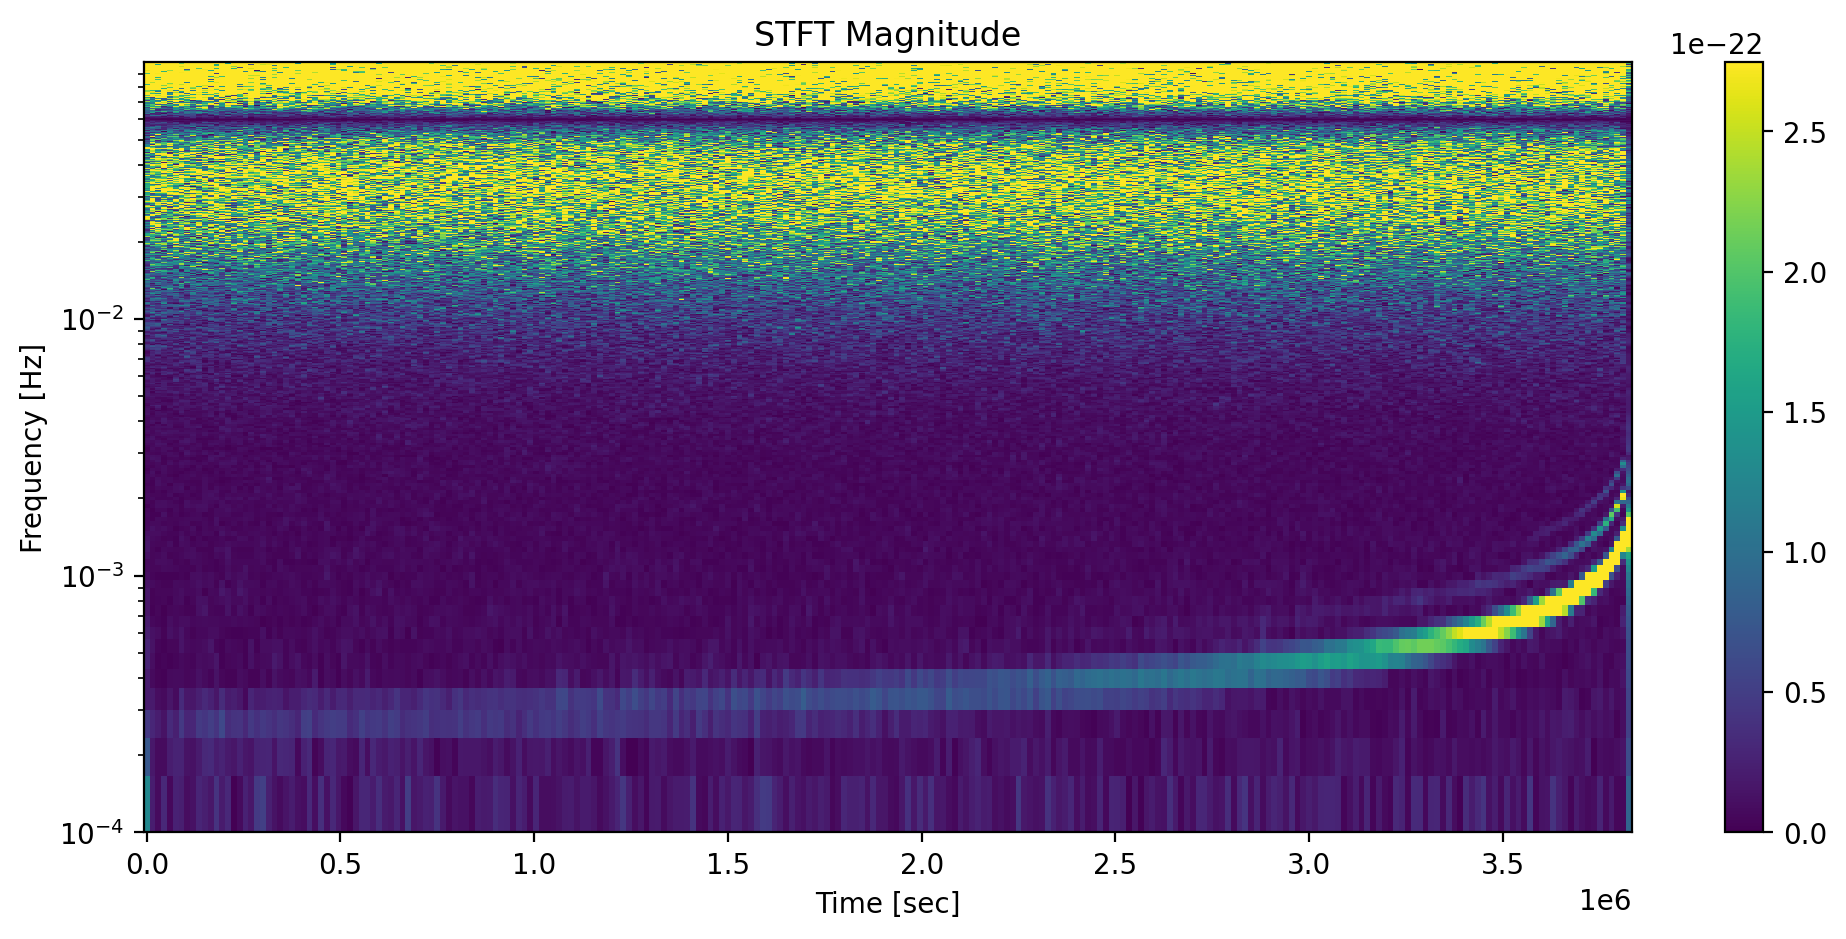

In [10]:
f, t, Zxx = sp.signal.stft(data_t_truncated[0], fs=1/sim.dt, nperseg=3000, noverlap=0)

print(f.shape, t.shape, f.shape[0]*t.shape[0])

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
#plt.xlim(t[-20], t[-3])
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar()

# Differential Evolution Analysis

In [11]:
boundaries = {}
boundaries['Total_Mass'] = [np.log(1e5), np.log(1e6)]   
boundaries['Mass_Ratio'] = [0.01, 0.99]
boundaries['Spin1'] = [-1, 1]
boundaries['Spin2'] = [-1, 1]
boundaries['Distance'] = [1, 50] # in GPc i.e. dL / (PC_SI * 1e9)
boundaries['Phase'] = [-np.pi, np.pi]
boundaries['cos(Inclination)'] = [-1, 1]
boundaries['Ecliptic_Longitude'] = [0, 2*np.pi]
boundaries['sin(Ecliptic_Latitude)'] = [-1, 1]
boundaries['Polarization'] = [0, np.pi]
boundaries['Coalescence_Time'] = [0, (max_time - cutoff_time)/(60*60*width_of_tref_prior)]

#boundaries['Coalescence_Time'] = [cutoff_time, max_time]  

In [12]:
number_of_searches = 1

differential_evolution_kwargs = {
    'strategy': 'rand1bin',
    'popsize': 8,
    'tol': 1e-8,
    'maxiter': 10,
    'recombination': 0.95,
    'mutation': (0.5, 1),
    'polish': False,
    'disp': True,
    'workers': -1,
    'updating': 'deferred',
    #'init': 'sobol',
}


fixed_parameters = {
    #'Total_Mass': np.log(m1 + m2),
    #'Mass_Ratio': m2 / m1,
    #'Spin1': a1,
    #'Spin2': a2,
    'Distance': boundaries['Distance'][0] + 0.5 * (boundaries['Distance'][1] - boundaries['Distance'][0]), # Always include distance in fixed parameters
    #'Phase': phi_ref,
    #'cos(Inclination)': np.cos(inc),
    #'Ecliptic_Longitude': lam,
    #'sin(Ecliptic_Latitude)': np.sin(beta),
    #'Polarization': psi,
    #'Coalescence_Time': (t_ref-cutoff_time)/(60*60*24),
}

# Time Frequency Domain

In [ ]:
analysis = TimeFreqSNR(
    data_t=sim.signal_t[0],
    wave_gen=wave_gen,
    nperseg=3000,
    dt_full=dt,
    cutoff_index=cutoff_index,
    pre_merger=False    
)
analysis.get_stft_of_data()
SNR, amplitude = analysis.calculate_time_frequency_SNR(*parameters, waveform_kwargs=waveform_kwargs)
new_distance = dist /  amplitude
print((new_distance - dist)/(PC_SI*1e9) , (new_distance-dist)/dist)
print( "True distance       = ",  dist/(PC_SI*1e9), "Gpc")
print( "Dist from Amplitude = ",  new_distance/(PC_SI*1e9), "Gpc")
print( "SNR calculated      = ",  SNR)

0.0 0.0
True distance       =  8.0 Gpc
Dist from Amplitude =  8.0 Gpc
SNR calculated      =  0.8887669535785362


In [27]:
# For full signal, use data_t =  sim.signal_t[0] , set pre_merger=False, and comment   cutoff_index = cutoff_index
# For pre-merger,  use data_t =  data_t_truncated, set pre_merger=True , and uncomment cutoff_index = cutoff_index
DifferentialEvolution_time_frequency_1 = MBHB_finder_time_frequency(
    data_t = sim.signal_t[0],
    wave_gen= wave_gen,
    waveform_kwargs=waveform_kwargs,
    boundaries=boundaries,
    nperseg=3000,
    dt_full= dt,
    pre_merger=False,
    cutoff_index=cutoff_index,
    cutoff_time=cutoff_time,
    true_parameters=parameters,
)
DifferentialEvolution_time_frequency_1.get_stft_of_data()

In [28]:
found_parameters_tf_1, found_snr_found_tf_1, results_tf_1, parameters_history_1 = DifferentialEvolution_time_frequency_1.find_MBHB(number_of_searches=number_of_searches,
                                                                                                                                   differential_evolution_kwargs=differential_evolution_kwargs, 
                                                                                                                                   fixed_parameters=None)

Starting differential evolution
No CuPy
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU PhenomHM module.
No CuPy or GPU response available.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy 

In [29]:
print(DifferentialEvolution_time_frequency_1)
print("Found parameters (Time-Frequency):", found_parameters_tf_1)
print("Found SNR:", found_snr_found_tf_1, "True SNR:", SNR)
print("Parameters history (Time-Frequency):", parameters_history_1)
print("Results (Time-Frequency):", results_tf_1)


Index Parameter                 Lower Bound    Found 1             True                 Upper Bound     Status    
------------------------------------------------------------------------------------------------------------------
0     Total_Mass                11.5129        13.2565             13.017               13.8155         variable  
1     Mass_Ratio                0.01           0.946812            0.5                  0.99            variable  
2     Spin1                     -1             -0.481962           0.2                  1               variable  
3     Spin2                     -1             0.715196            0.4                  1               variable  
4     Distance                  1              50.8371             8                    50              variable  
5     Phase                     -3.14159       1.95471             0.577                3.14159         variable  
6     cos(Inclination)          -1             0.87679             0.5          

In [35]:
parameters_history_1[:,6]

array([4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550364,
       4.98550364, 4.98550364, 4.98550364, 4.98550364, 4.98550

In [14]:
found_tref = transform_parameters_to_bbhx(found_parameters_tf_1, cutoff_time=cutoff_time)[-1]
print(found_tref, t_ref, found_tref - t_ref)
print(found_parameters_tf_1)

4995761.848136492 4996707.045894721 -945.1977582285181
[12.94803068  0.83082222  0.35650593  0.77825984  9.00562452  1.67842343
  0.41318412  4.98550365  0.23088296  2.23053486  0.82239354]


In [ ]:
"""save_de_results(
    found_parameters_tf_1,
    found_snr_found_tf_1,
    SNR,
    results_tf_1,
    parameters_history_1,
    folder_name="euler_output",
    filename_prefix="tf_run"
)"""

something = [1.30170029e+01, 5.00000000e-01, 7.53000000e-01, 6.21000000e-01, 1.01848471e+01, 0.00000000e+00, 3.38441676e-01, 3.50922963e+00, 3.88612784e-01, 3.13411572e+00, 7.20357732e+04]

In [ ]:
"""bounds = np.array(list(boundaries.values()))
bounds = np.delete(bounds, 4, axis=0)
initial = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(len(bounds),))
DifferentialEvolution_time_frequency_1.calculate_time_frequency_SNR_without_distance(initial, fixed_parameters=fixed_parameters)"""

In [ ]:
found_parameters = np.array([12.9675, 0.684924, 0.524065, 0.999998, 10.1203, -1.82545, 0.345506, 3.51093, 0.292316, 1.57164, 72000])
found_SNR = 0.06530506
found_parameters_bbhx = transform_parameters_to_bbhx(found_parameters, cutoff_time=cutoff_time)
found_parameters_bbhx

array([ 2.54175319e+05,  1.74090776e+05,  5.24065000e-01,  9.99998000e-01,
        3.12279828e+26, -1.82545000e+00,  0.00000000e+00,  1.21801839e+00,
        3.51093000e+00,  2.96647723e-01,  1.57164000e+00,  2.49835352e+06])

In [22]:
recovered_wave = wave_gen(*found_parameters_bbhx, **waveform_kwargs)[0][:2]
injected_wave = sim.signal_f[0]

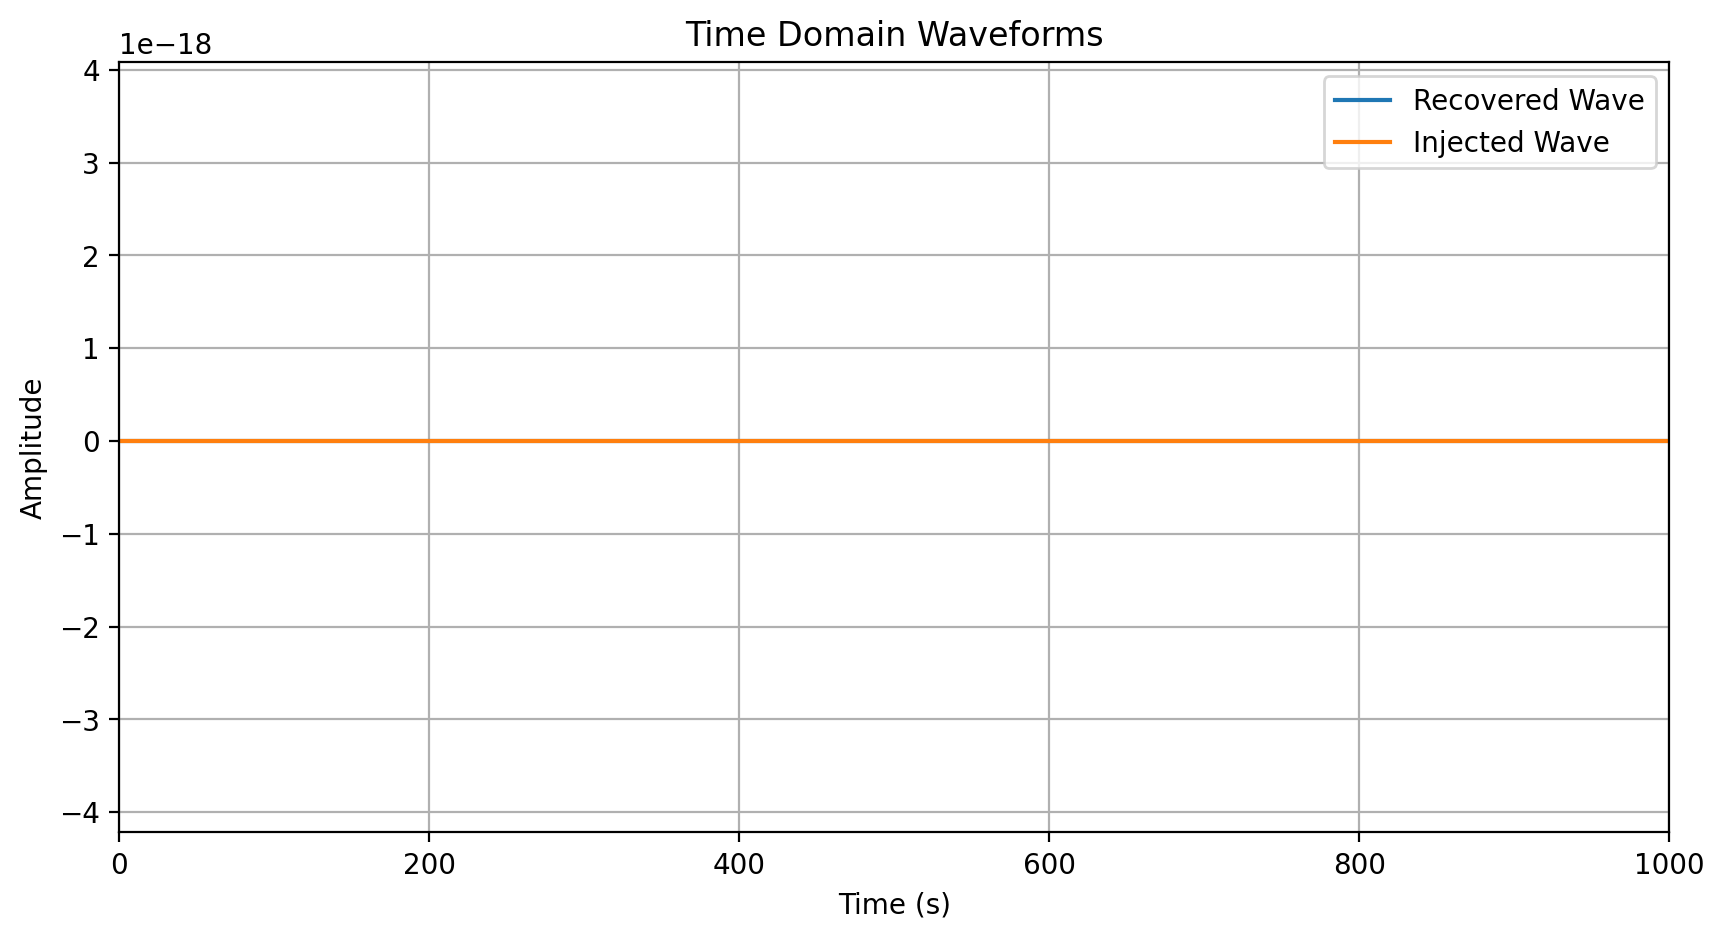

In [37]:
recovered_wave_t_A = np.fft.irfft(recovered_wave[0])
injected_wave_t_A = np.fft.irfft(injected_wave[0])
plt.figure(figsize=(10, 5))
plt.plot(t_array, recovered_wave_t_A, label='Recovered Wave')
plt.plot(t_array, injected_wave_t_A, label='Injected Wave')
plt.xlim(t_ref-100, t_ref+1400)
plt.xlim(0, 1000)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Time Domain Waveforms')
plt.legend()
plt.grid()
plt.show()

In [ ]:
x0 = load_de_results(filepath='differential_evolution_results/tf_run_20250820_132453.npz')["result_x"]
#differential_evolution_kwargs.update({'x0': x0})

import numpy as np

dim = len(x0)
popsize = 10    # smaller is fine for local refinement
perturb_scale = 0.17  # 5% spread relative to bounds

# assuming you have parameter bounds as a list of (low, high) tuples
parameter_names = list(boundaries.keys())
variable_parameter_names = [name for name in parameter_names if name not in fixed_parameters.keys()]
bounds = np.array([boundaries[name] for name in variable_parameter_names])
bounds

population = []
for i in range(popsize * dim):
    candidate = []
    for j, (low, high) in enumerate(bounds):
        span = high - low
        # add noise scaled to parameter range
        val = x0[j] + np.random.normal(scale=perturb_scale * span)
        # clip to bounds
        val = np.clip(val, low, high)
        candidate.append(val)
    population.append(candidate)

population = np.array(population)

differential_evolution_kwargs_new = {
    'init': population,
    #'x0': x0, # optional, for polish
    'polish': True,
    'disp': True,
    
    #'strategy': 'rand1bin',
    #'tol': 1e-8,
    #'maxiter': 1000,
    #'recombination': 0.95,
    #'mutation': (0.5, 1),
    #'workers': -1,
    #'updating': 'deferred',
}

# Frequency Domain

In [ ]:
template = wave_gen(*parameters,**waveform_kwargs)[0, :2]

print(likelihood.template_snr(sim.signal_f[0], template, AE1SensitivityMatrix(f_array), df=sim.df))

hh = get_hh(template, AE1SensitivityMatrix(f_array), df=sim.df)
dh = get_dh(sim.signal_f[0], template, AE1SensitivityMatrix(f_array), df=sim.df)
amplitude = dh/hh
new_distance = dist /  amplitude

print( "Percentage diff     = ", (new_distance-dist)*100/dist , "%" )
print( "True distance       = ",  dist/(PC_SI*1e9), "Gpc")
print( "Dist from Amplitude = ",  new_distance/(PC_SI*1e9), "Gpc")
print( "SNR calculated      = " , dh/np.sqrt(hh))

In [ ]:
DifferentialEvolution_frequency_domain= MBHB_finder_frequency_domain(
    data_f=data_f,
    wave_gen=wave_gen,
    waveform_kwargs=waveform_kwargs,
    boundaries=boundaries,
    true_parameters=parameters,
    cutoff_time=cutoff_time
)

DifferentialEvolution_frequency_domain.prepare_data(f_array=f_array, df=sim.df)
found_parameters_fd, found_snr_found_fd, results_fd, parameters_history_fd = DifferentialEvolution_frequency_domain.find_MBHB(number_of_searches=number_of_searches,
                                                                             differential_evolution_kwargs=differential_evolution_kwargs, 
                                                                             fixed_parameters=None)

In [ ]:
print(DifferentialEvolution_frequency_domain), results_fd

# Lisatools

In [ ]:
DifferentialEvolution_lisatools= MBHB_finder_lisatools(
    data_f=data_f,
    sens_mat=AE1SensitivityMatrix(f=f_array),
    wave_gen=wave_gen,
    waveform_kwargs=waveform_kwargs,
    f_array=f_array,
    boundaries=boundaries,
    true_parameters=parameters,
)


DifferentialEvolution_lisatools.get_analysis_container_of_data()

found_parameters_lisatools, found_snr_found_lisatools, results_lisatools = DifferentialEvolution_lisatools.find_MBHB(number_of_searches=number_of_searches,
                                                                             differential_evolution_kwargs=differential_evolution_kwargs, 
                                                                             fixed_parameters=fixed_parameters)
# The number of messages like "No CuPy or GPU PhenomHM module" you see is exactly equal to the number of workers used. On this macbook, it has 11 cores, so there are 11 messages. Imma just live with this

In [ ]:
print(DifferentialEvolution_lisatools)
print(results_lisatools)

- The reason why the distance estimate can be so bad (sometimes even outside the priors) is because it is calculated from the amplitude that is calculated with a template generated by the other found parameters
- The other found parameters don't have to be close to the true parameters, unless you run it for longer
- With low tolarance, high popsize, and high maxiter, it works properly but takes a long time to run

In [ ]:
import os
os.system("say 'Computation is done!'")

# The SNR does not depend on the distance. 
Change the guess_distance to see that the SNR is the same. The distance is calculated based on the amplitude.
- This only works when all the other parameters in template are set to the real values. 
- The hope is to use differential_evolution to calculate the remaining parameters reasonably well and get an estimate of distance from that

In [ ]:
guess_distance = dist * 1000
signal_with_which_to_test_this = sim.signal_f[0] #data_f
template = wave_gen(
    m1,
    m2,
    a1,
    a2,
    guess_distance, 
    phi_ref,
    f_ref, 
    inc,
    lam,
    beta,
    psi,
    t_ref,
    **waveform_kwargs
)
template = template[0, :2]
print(likelihood.template_snr(signal_with_which_to_test_this, template, AE1SensitivityMatrix(f_array), df=sim.df))

hh = get_hh(template, AE1SensitivityMatrix(f_array), df=sim.df)
dh = get_dh(signal_with_which_to_test_this, template, AE1SensitivityMatrix(f_array), df=sim.df)
amplitude = dh/hh
new_distance = guess_distance /  amplitude

print( "Percentage diff     = ", (new_distance-dist)*100/dist , "%" )
print( "True distance       = ",  dist/(PC_SI*1e9), "Gpc")
print( "Dist from Amplitude = ",  new_distance/(PC_SI*1e9), "Gpc")
print( "SNR calculated      = " , dh/np.sqrt(hh))

The SNR also does not change with the time-frequency SNR with pre-merger. Change guess_distance and see that nothing changes.
- Again, this only works when all the other parameters in template are set to the real values. 
- The hope is to use differential_evolution to calculate the remaining parameters reasonably well and get an estimate of distance from that.
- But it's good that using time-freq SNR also works to get the distance.
- Change the value of, say, m1 drastically and see that the distance estimate from the equation is awful, which makes sense.

In [ ]:
guess_distance = dist 
parameters_new = [
    m1*(1),  # Slightly change m1 to see the effect
    m2,
    a1*(1),  # Slightly change a1 to see the effect
    a2,
    guess_distance,
    phi_ref,
    f_ref,
    inc*(1 ),
    lam,
    beta,
    psi,
    t_ref
]
analysis = TimeFreqSNR(
    data_t_truncated,
    wave_gen=wave_gen,
    nperseg=5000,
    dt_full=dt,
    cutoff_index=cutoff_index,
    pre_merger=True
)
analysis.get_stft_of_data()
SNR, amplitude = analysis.calculate_time_frequency_SNR(*parameters_new, waveform_kwargs=waveform_kwargs)
new_distance = guess_distance /  amplitude
print((new_distance - dist)/(PC_SI*1e9) , (new_distance-dist)/dist)
print( "True distance       = ",  dist/(PC_SI*1e9), "Gpc")
print( "Dist from Amplitude = ",  new_distance/(PC_SI*1e9), "Gpc")
print( "SNR calculated      = ",  SNR)